In [1]:
#Imports & Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True


In [41]:
#Load CSVs
baseline_df = pd.read_csv("../results/baseline_eval.csv")
standard_df = pd.read_csv("../results/standard_eval.csv")
robustness_df = pd.read_csv("../results/robustness_eval.csv")
seed_df = pd.read_csv("../results/seed_sensitivity.csv")
size_df = pd.read_csv("../results/size_sensitivity.csv")
stability_df = pd.read_csv("../results/stability_eval.csv")
error_df = pd.read_csv("../results/error_analysis_detailed.csv")

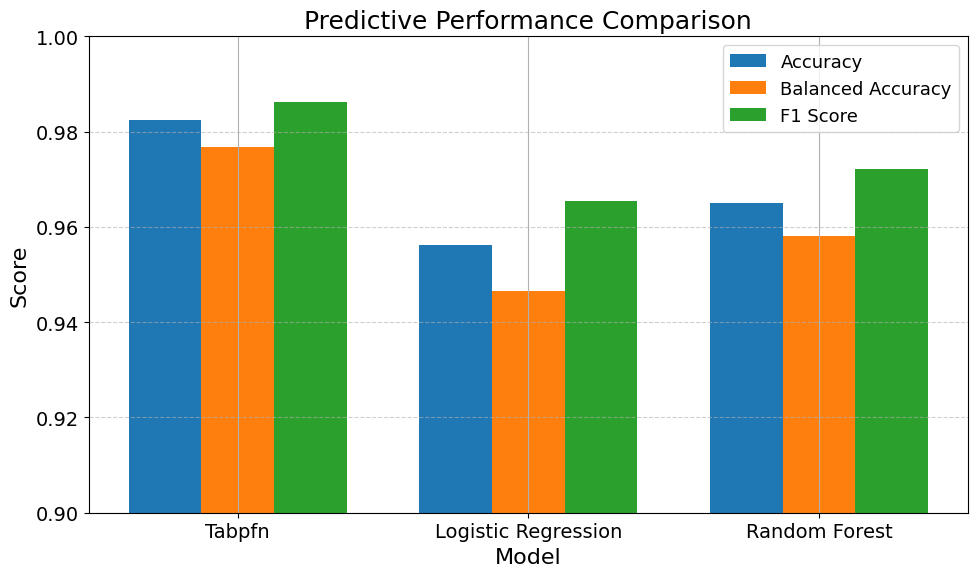

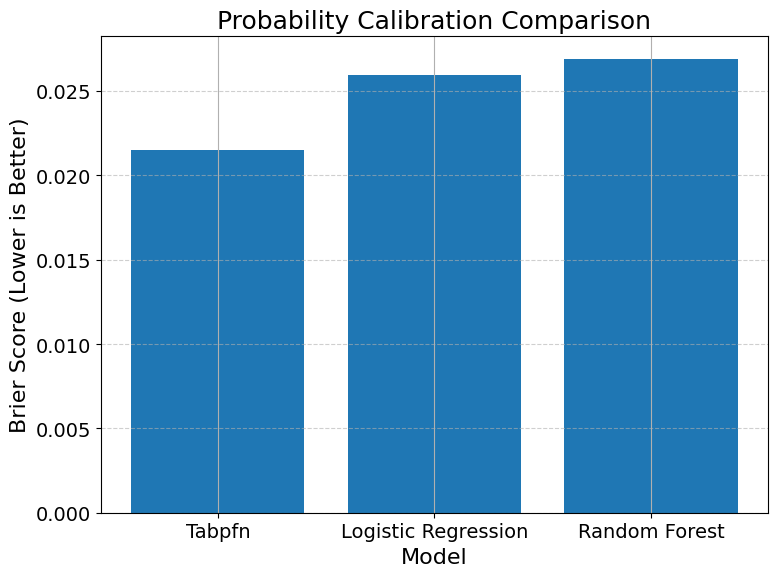

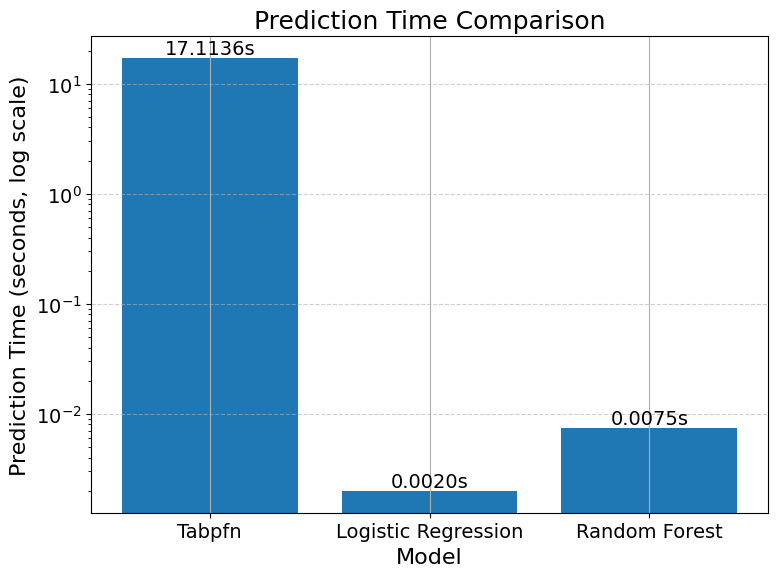

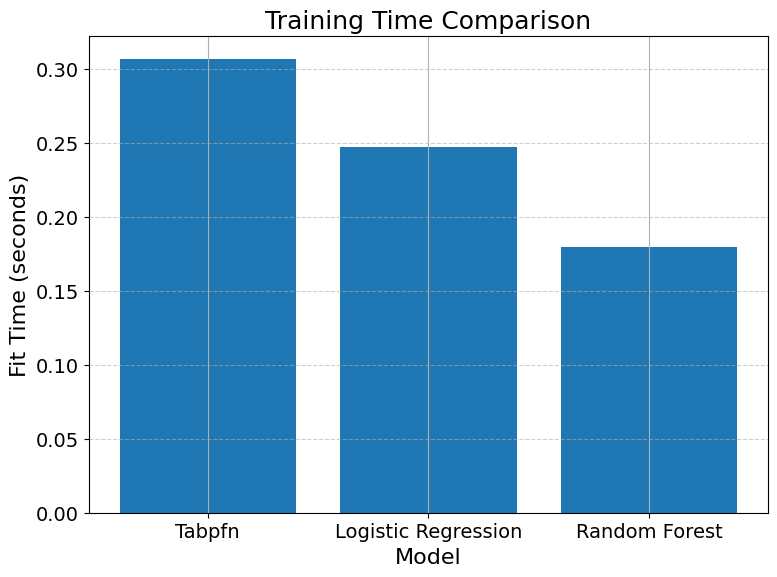

In [ ]:

#Baseline Visualization - Comparision of tabpfn , random_forest and logistic_regression on breast_cancer
# Load your summary CSV
df = baseline_df
# Clean model names if needed
df["model"] = df["model"].str.replace("_", " ").str.title()
# Set global style for poster-quality visuals
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "legend.fontsize": 13,
    "figure.titlesize": 20
})

# =========================
# Plot 1: Accuracy vs Balanced Accuracy vs F1
# =========================

metrics = ["accuracy", "balanced_accuracy", "f1_score"]
x = np.arange(len(df["model"]))
width = 0.25

plt.figure(figsize=(10,6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, df[metric], width, label=metric.replace("_", " ").title())

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Predictive Performance Comparison")
plt.xticks(x + width, df["model"])
plt.ylim(0.9, 1.0)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/baseline_plot_performance_comparison.png", dpi=300)
plt.show()


# =========================
# Plot 2: Brier Score Comparison
# =========================

plt.figure(figsize=(8,6))

plt.bar(df["model"], df["brier_score"])
plt.xlabel("Model")
plt.ylabel("Brier Score (Lower is Better)")
plt.title("Probability Calibration Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/baseline_plot_brier_score.png", dpi=300)
plt.show()


# =========================
# Plot 3: Prediction Time Comparison
# =========================

plt.figure(figsize=(8,6))

bars = plt.bar(df["model"], df["predict_time"])

plt.yscale("log")

plt.xlabel("Model")
plt.ylabel("Prediction Time (seconds, log scale)")
plt.title("Prediction Time Comparison")

# add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}s",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/baseline_plot_prediction_time_log.png", dpi=300)
plt.show()

# =========================
# Plot 4: Fit Time Comparison
# =========================

plt.figure(figsize=(8,6))

plt.bar(df["model"], df["fit_time"])
plt.xlabel("Model")
plt.ylabel("Fit Time (seconds)")
plt.title("Training Time Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/baseline_plot_fit_time.png", dpi=300)
plt.show()


Averaged summary:
         dataset   model  accuracy  balanced_accuracy  f1_score  fit_time  \
0   Adult Income  TabPFN  0.846248           0.751265  0.639099  0.214081   
1  Breast Cancer  TabPFN  0.980702           0.976786  0.984807  0.240056   
2   Wine Quality  TabPFN  0.777500           0.776098  0.777335  0.246958   

   predict_time  
0     84.324269  
1      9.475908  
2     10.723129  


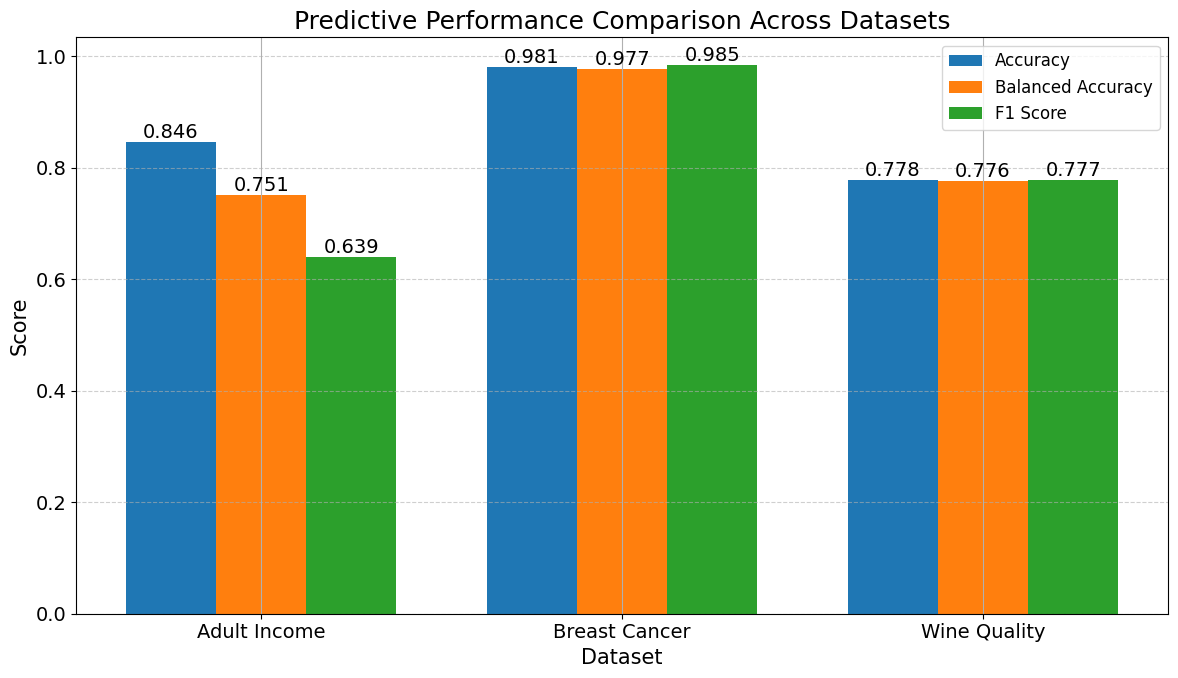

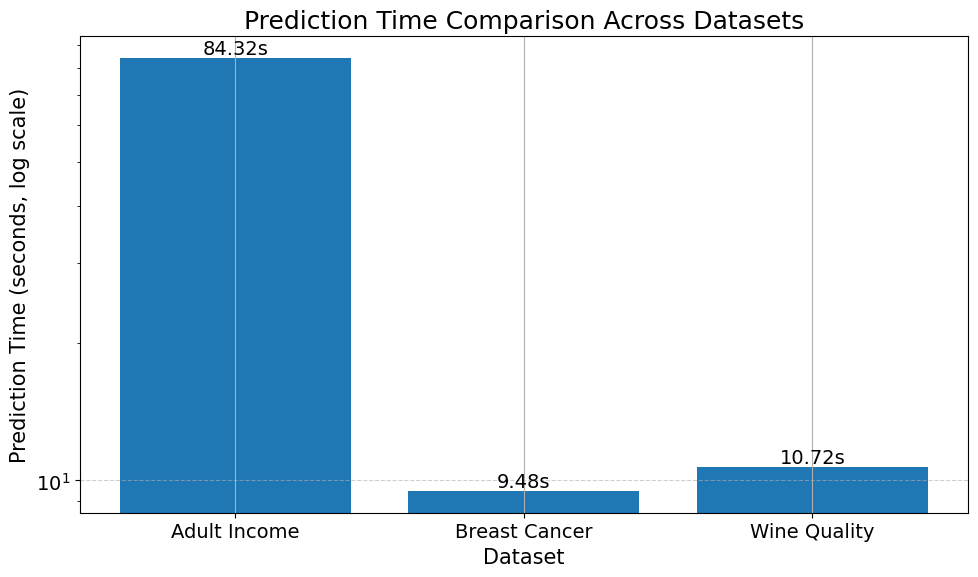

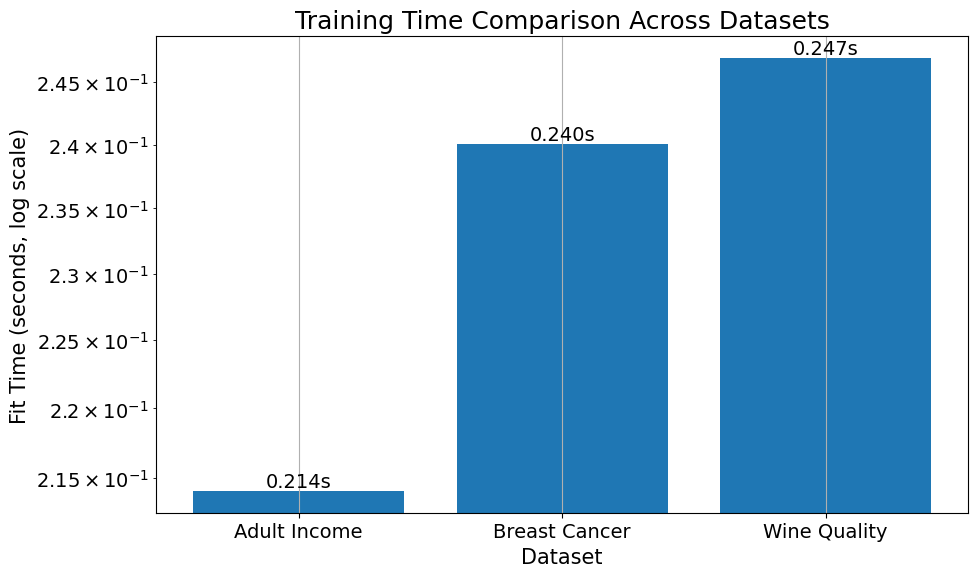

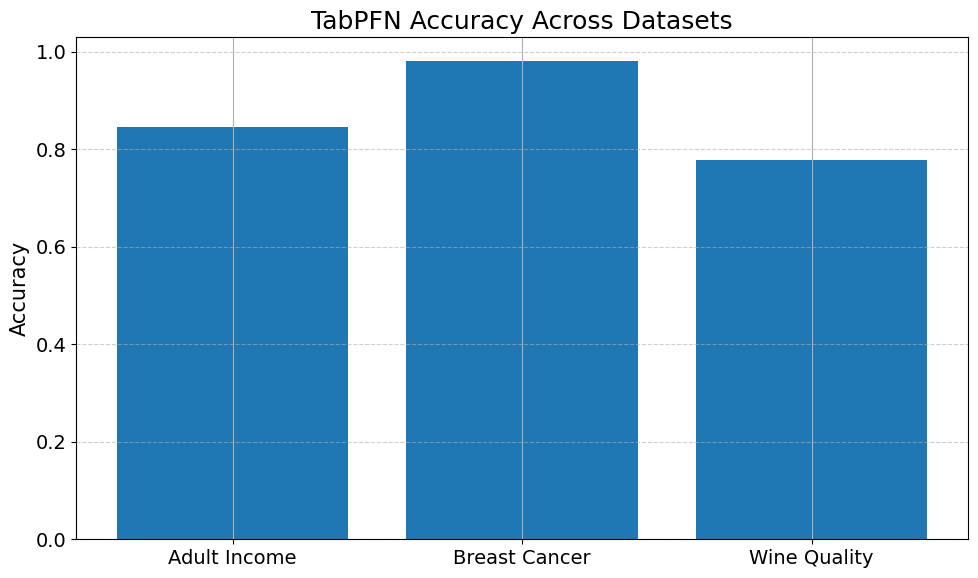

In [ ]:

#Standard Visualization - Visualization 2
#Comparing 3 datasets on tabpfn with multiple results
# ============================================================
# STEP 1: LOAD DATA
# ============================================================

df = standard_df
# ============================================================
# STEP 2: GROUP AND AVERAGE ACROSS SEEDS
# ============================================================
# This gives true performance, not seed-specific noise

summary = df.groupby(["dataset", "model"]).agg({
    "accuracy": "mean",
    "balanced_accuracy": "mean",
    "f1_score": "mean",
    "fit_time": "mean",
    "predict_time": "mean"
}).reset_index()

print("\nAveraged summary:")
print(summary)


# ============================================================
# STEP 3: SET PLOT STYLE (poster quality)
# ============================================================

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "legend.fontsize": 12
})

# ============================================================
# PLOT 1: PERFORMANCE COMPARISON PER DATASET
# ============================================================
# Shows accuracy, balanced accuracy, F1 for each dataset
# ============================================================
# STEP 3: CREATE GROUPED BAR CHART
# ============================================================

x = np.arange(len(summary["dataset"]))
width = 0.25

plt.figure(figsize=(12,7))

# Bars
bars1 = plt.bar(x - width, summary["accuracy"], width, label="Accuracy")
bars2 = plt.bar(x, summary["balanced_accuracy"], width, label="Balanced Accuracy")
bars3 = plt.bar(x + width, summary["f1_score"], width, label="F1 Score")

# Labels
plt.xlabel("Dataset")
plt.ylabel("Score")
plt.title("Predictive Performance Comparison Across Datasets")

plt.xticks(x, summary["dataset"])

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.6)

# ============================================================
# ADD VALUE LABELS
# ============================================================

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom"
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

# Save
plt.tight_layout()
plt.savefig("../results/standard_performance_all_datasets.png", dpi=300)

plt.show()
# ============================================================
# STEP 3: PREDICTION TIME COMPARISON (ALL DATASETS IN ONE GRAPH)
# ============================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    summary["dataset"],
    summary["predict_time"]
)

# Use log scale due to huge differences
plt.yscale("log")

plt.xlabel("Dataset")
plt.ylabel("Prediction Time (seconds, log scale)")
plt.title("Prediction Time Comparison Across Datasets")

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}s",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/standard_prediction_time_all_datasets.png", dpi=300)
plt.show()


# ============================================================
# STEP 4: FIT TIME COMPARISON (ALL DATASETS IN ONE GRAPH)
# ============================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    summary["dataset"],
    summary["fit_time"]
)

plt.yscale("log")

plt.xlabel("Dataset")
plt.ylabel("Fit Time (seconds, log scale)")
plt.title("Training Time Comparison Across Datasets")

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}s",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/standard_fit_time_all_datasets.png", dpi=300)
plt.show()

# ============================================================
# PLOT 4: CROSS-DATASET PERFORMANCE COMPARISON
# ============================================================
# Shows how TabPFN performs across datasets

tabpfn_only = summary[summary["model"] == "TabPFN"]

plt.figure(figsize=(10,6))

plt.bar(tabpfn_only["dataset"], tabpfn_only["accuracy"])

plt.ylabel("Accuracy")
plt.title("TabPFN Accuracy Across Datasets")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()

plt.savefig("../results/standard_tabpfn_cross_dataset_accuracy.png", dpi=300)

plt.show()


<Figure size 1000x600 with 0 Axes>

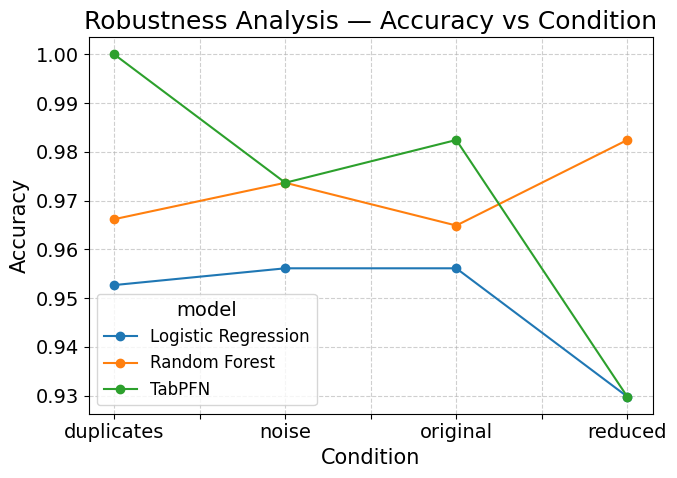

<Figure size 1000x600 with 0 Axes>

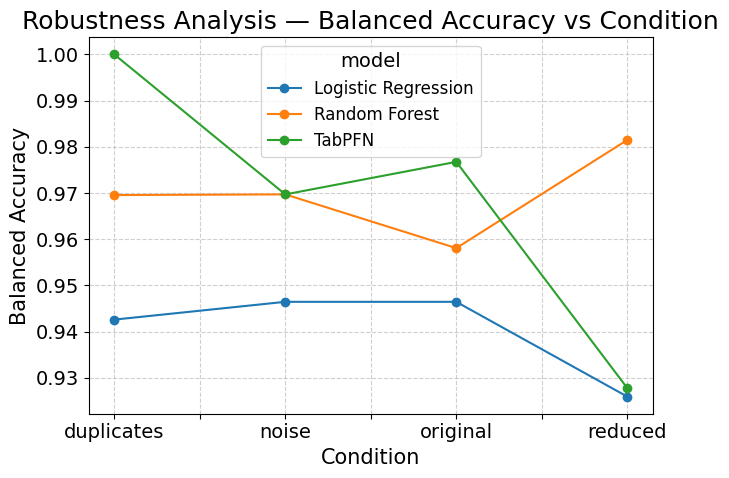

<Figure size 1000x600 with 0 Axes>

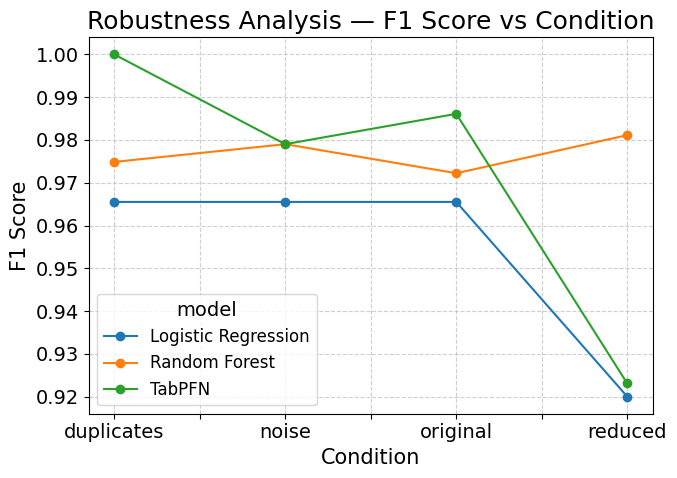

<Figure size 1000x600 with 0 Axes>

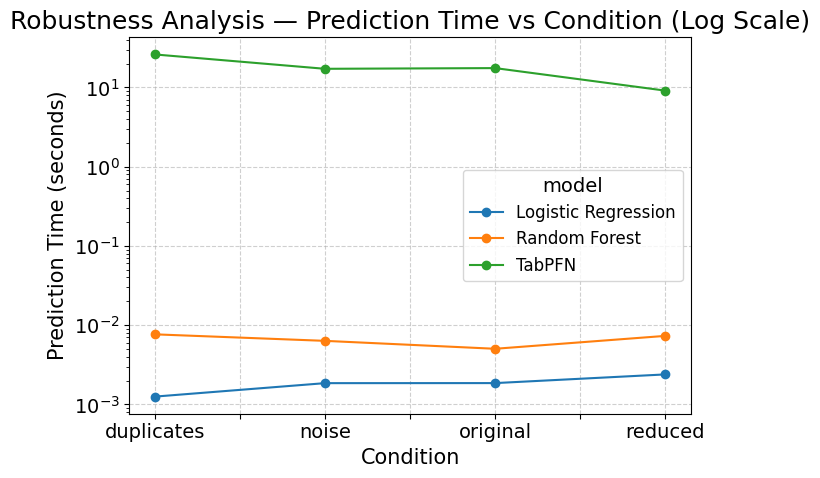

Generated:
robustness_accuracy.png
robustness_balanced_accuracy.png
robustness_f1_score.png
robustness_predict_time.png


In [ ]:
#VISUALIZATION 3
#Robustness Analysis 
#Done on breast cancer by all 3 models
# ============================================================
# PLOT 1: ACCURACY ROBUSTNESS (YOUR CURRENT PLOT, CLEANED)
# ============================================================


accuracy_plot = robustness_df.groupby(
    ["condition", "model"]
)["accuracy"].mean().unstack()

plt.figure(figsize=(10,6))

accuracy_plot.plot(marker="o")

plt.title("Robustness Analysis — Accuracy vs Condition")
plt.ylabel("Accuracy")
plt.xlabel("Condition")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/robustness_accuracy.png", dpi=300)

plt.show()


# ============================================================
# PLOT 2: BALANCED ACCURACY ROBUSTNESS
# ============================================================

balanced_plot = robustness_df.groupby(
    ["condition", "model"]
)["balanced_accuracy"].mean().unstack()

plt.figure(figsize=(10,6))

balanced_plot.plot(marker="o")

plt.title("Robustness Analysis — Balanced Accuracy vs Condition")
plt.ylabel("Balanced Accuracy")
plt.xlabel("Condition")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/robustness_balanced_accuracy.png", dpi=300)

plt.show()


# ============================================================
# PLOT 3: F1 SCORE ROBUSTNESS
# ============================================================

f1_plot = robustness_df.groupby(
    ["condition", "model"]
)["f1_score"].mean().unstack()

plt.figure(figsize=(10,6))

f1_plot.plot(marker="o")

plt.title("Robustness Analysis — F1 Score vs Condition")
plt.ylabel("F1 Score")
plt.xlabel("Condition")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/robustness_f1_score.png", dpi=300)

plt.show()


# ============================================================
# PLOT 4: PREDICTION TIME ROBUSTNESS (LOG SCALE)
# ============================================================

predict_plot = robustness_df.groupby(
    ["condition", "model"]
)["predict_time"].mean().unstack()

plt.figure(figsize=(10,6))

predict_plot.plot(marker="o")

plt.yscale("log")

plt.title("Robustness Analysis — Prediction Time vs Condition (Log Scale)")
plt.ylabel("Prediction Time (seconds)")
plt.xlabel("Condition")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/robustness_predict_time.png", dpi=300)

plt.show()


# ============================================================
# DONE
# ============================================================

print("Generated:")
print("robustness_accuracy.png")
print("robustness_balanced_accuracy.png")
print("robustness_f1_score.png")
print("robustness_predict_time.png")



<Figure size 1000x600 with 0 Axes>

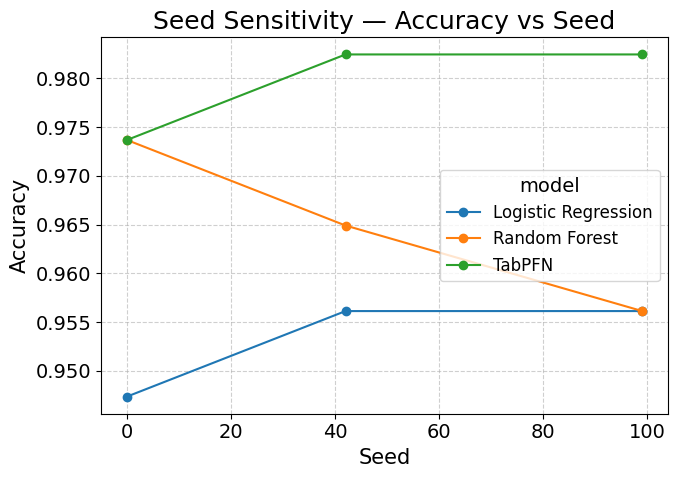

<Figure size 1000x600 with 0 Axes>

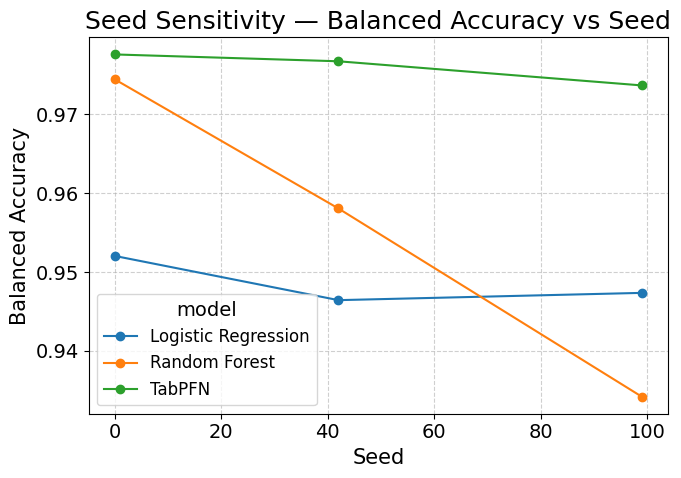

<Figure size 1000x600 with 0 Axes>

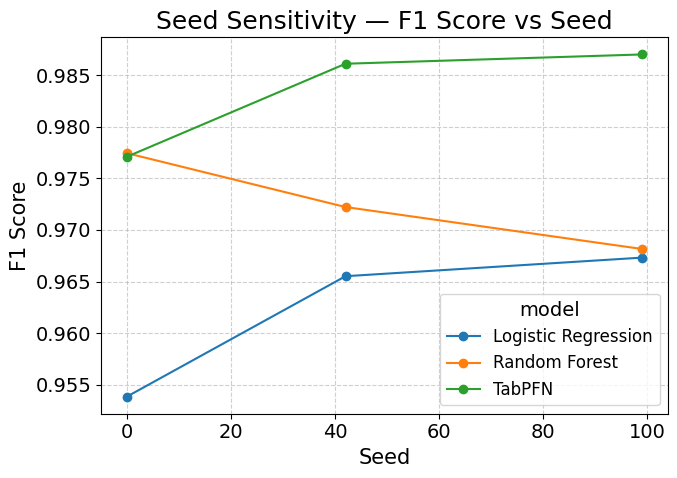

<Figure size 1000x600 with 0 Axes>

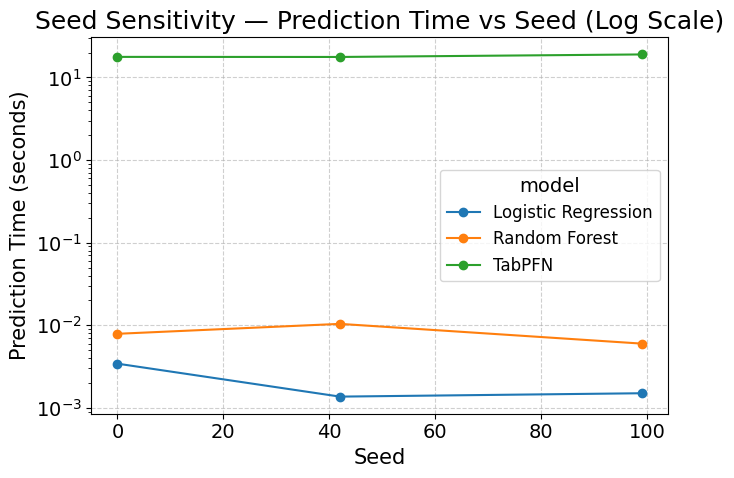

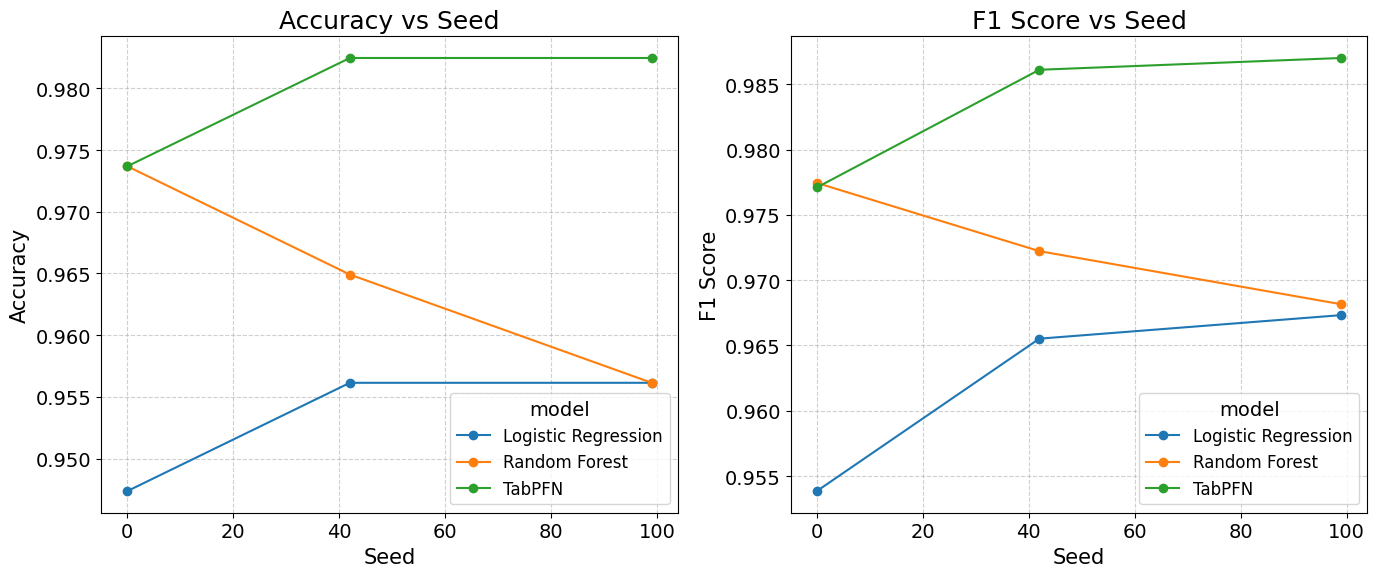

Generated:
seed_sensitivity_accuracy.png
seed_sensitivity_balanced_accuracy.png
seed_sensitivity_f1.png
seed_sensitivity_predict_time.png
seed_sensitivity_combined.png


In [28]:
#VISUALIZATION 4 -Done on breast cancer by all 3 datasets
#Seed Sensitivity — Accuracy Across Seeds
# ============================================================
# STEP 2: ACCURACY PLOT
# ============================================================

accuracy_plot = seed_df.pivot(
    index="seed",
    columns="model",
    values="accuracy"
)

plt.figure(figsize=(10,6))

accuracy_plot.plot(marker="o")

plt.title("Seed Sensitivity — Accuracy vs Seed")
plt.ylabel("Accuracy")
plt.xlabel("Seed")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/seed_sensitivity_accuracy.png", dpi=300)

plt.show()


# ============================================================
# STEP 3: BALANCED ACCURACY PLOT
# ============================================================

balanced_plot = seed_df.pivot(
    index="seed",
    columns="model",
    values="balanced_accuracy"
)

plt.figure(figsize=(10,6))

balanced_plot.plot(marker="o")

plt.title("Seed Sensitivity — Balanced Accuracy vs Seed")
plt.ylabel("Balanced Accuracy")
plt.xlabel("Seed")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/seed_sensitivity_balanced_accuracy.png", dpi=300)

plt.show()


# ============================================================
# STEP 4: F1 SCORE PLOT
# ============================================================

f1_plot = seed_df.pivot(
    index="seed",
    columns="model",
    values="f1_score"
)

plt.figure(figsize=(10,6))

f1_plot.plot(marker="o")

plt.title("Seed Sensitivity — F1 Score vs Seed")
plt.ylabel("F1 Score")
plt.xlabel("Seed")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/seed_sensitivity_f1.png", dpi=300)

plt.show()


# ============================================================
# STEP 5: PREDICTION TIME PLOT (LOG SCALE)
# ============================================================

predict_plot = seed_df.pivot(
    index="seed",
    columns="model",
    values="predict_time"
)

plt.figure(figsize=(10,6))

predict_plot.plot(marker="o")

plt.yscale("log")

plt.title("Seed Sensitivity — Prediction Time vs Seed (Log Scale)")
plt.ylabel("Prediction Time (seconds)")
plt.xlabel("Seed")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/seed_sensitivity_predict_time.png", dpi=300)

plt.show()


# ============================================================
# STEP 6: COMBINED SUBPLOT (BEST FOR POSTER)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14,6))

accuracy_plot.plot(marker="o", ax=axes[0])
axes[0].set_title("Accuracy vs Seed")
axes[0].set_xlabel("Seed")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, linestyle="--", alpha=0.6)

f1_plot.plot(marker="o", ax=axes[1])
axes[1].set_title("F1 Score vs Seed")
axes[1].set_xlabel("Seed")
axes[1].set_ylabel("F1 Score")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/seed_sensitivity_combined.png", dpi=300)

plt.show()


# ============================================================
# DONE
# ============================================================

print("Generated:")
print("seed_sensitivity_accuracy.png")
print("seed_sensitivity_balanced_accuracy.png")
print("seed_sensitivity_f1.png")
print("seed_sensitivity_predict_time.png")
print("seed_sensitivity_combined.png")


<Figure size 1000x600 with 0 Axes>

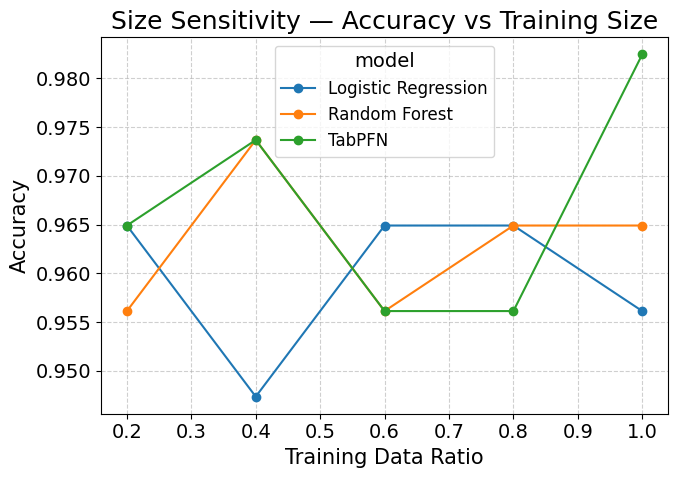

<Figure size 1000x600 with 0 Axes>

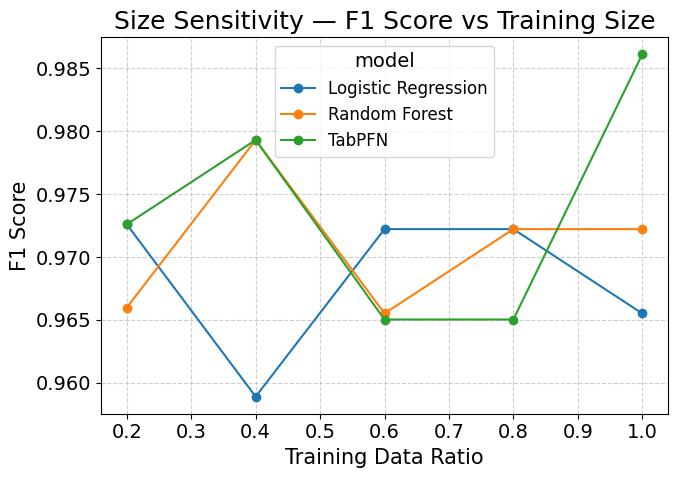

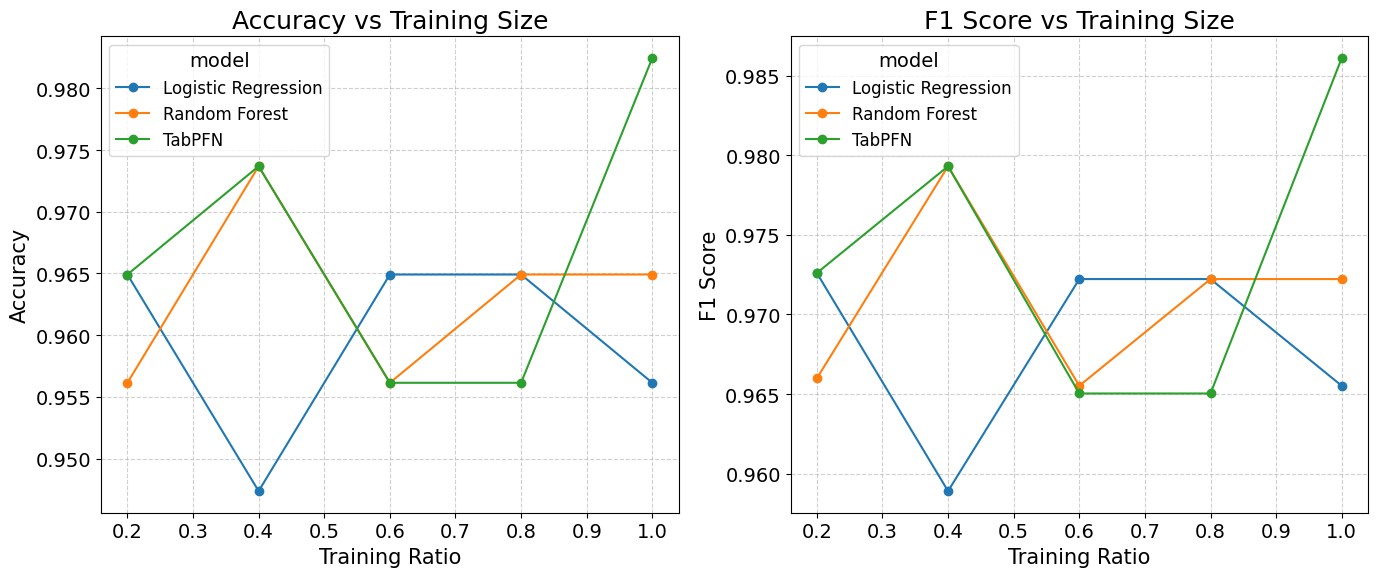

Generated:
size_sensitivity_accuracy.png
size_sensitivity_f1.png
size_sensitivity_combined.png


In [ ]:
#VISUALIZATION 5
#Size Sensitivity - Done on breast cancer by all 3 models
# ============================================================
# STEP 2: EXTRACT NUMERIC TRAIN RATIOS
# ============================================================

size_df["train_ratio"] = (
    size_df["condition"]
    .str.replace("train_ratio_", "", regex=False)
    .astype(float)
)


# ============================================================
# STEP 3: ACCURACY PLOT
# ============================================================

accuracy_plot = size_df.pivot(
    index="train_ratio",
    columns="model",
    values="accuracy"
)

plt.figure(figsize=(10,6))

accuracy_plot.plot(marker="o")

plt.title("Size Sensitivity — Accuracy vs Training Size")
plt.ylabel("Accuracy")
plt.xlabel("Training Data Ratio")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/size_sensitivity_accuracy.png", dpi=300)

plt.show()


# ============================================================
# STEP 4: F1 SCORE PLOT
# ============================================================

f1_plot = size_df.pivot(
    index="train_ratio",
    columns="model",
    values="f1_score"
)

plt.figure(figsize=(10,6))

f1_plot.plot(marker="o")

plt.title("Size Sensitivity — F1 Score vs Training Size")
plt.ylabel("F1 Score")
plt.xlabel("Training Data Ratio")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/size_sensitivity_f1.png", dpi=300)

plt.show()


# ============================================================
# STEP 5: COMBINED SUBPLOT (BEST FOR POSTER)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Accuracy subplot
accuracy_plot.plot(marker="o", ax=axes[0])
axes[0].set_title("Accuracy vs Training Size")
axes[0].set_xlabel("Training Ratio")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, linestyle="--", alpha=0.6)

# F1 subplot
f1_plot.plot(marker="o", ax=axes[1])
axes[1].set_title("F1 Score vs Training Size")
axes[1].set_xlabel("Training Ratio")
axes[1].set_ylabel("F1 Score")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/size_sensitivity_combined.png", dpi=300)

plt.show()

# ============================================================
# DONE
# ============================================================

print("Generated:")
print("size_sensitivity_accuracy.png")
print("size_sensitivity_f1.png")
print("size_sensitivity_combined.png")


<Figure size 1000x600 with 0 Axes>

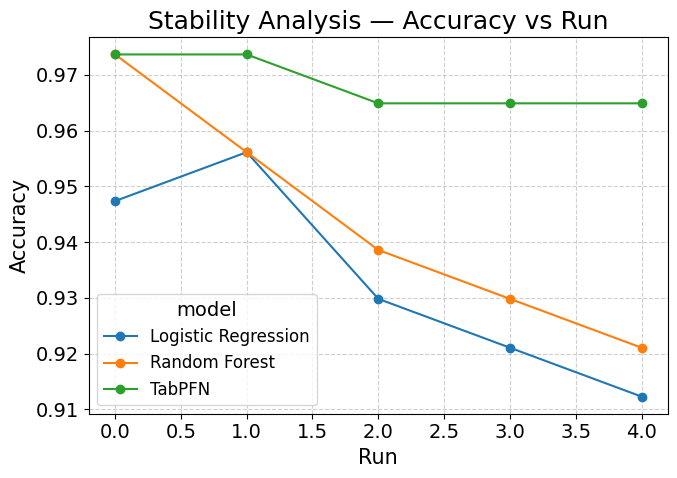

<Figure size 1000x600 with 0 Axes>

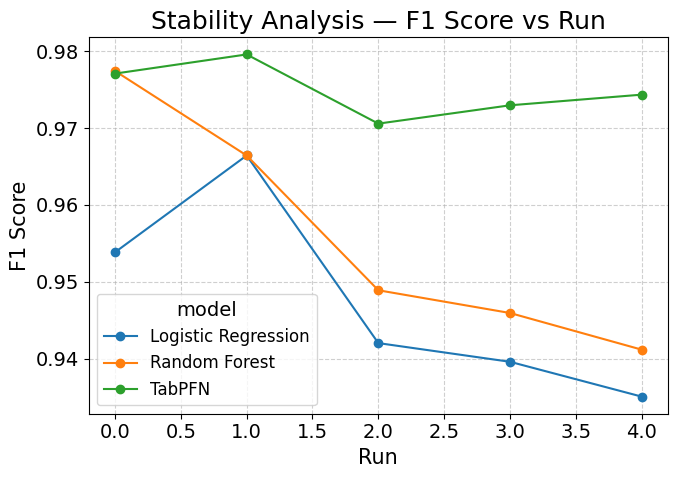

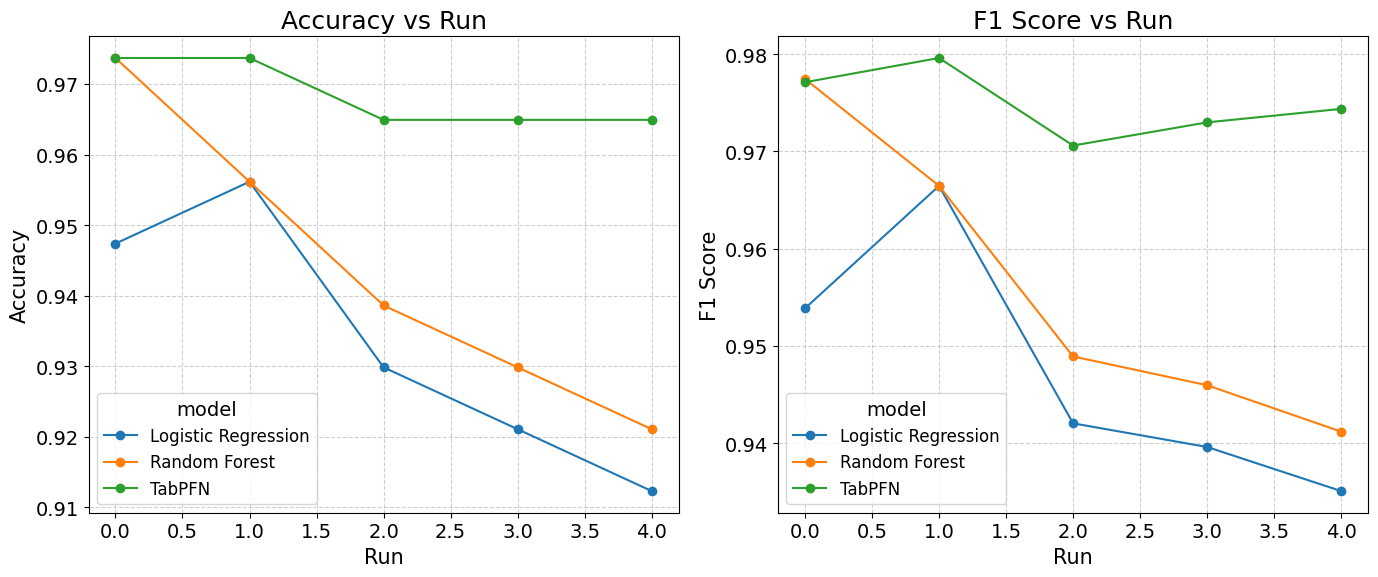

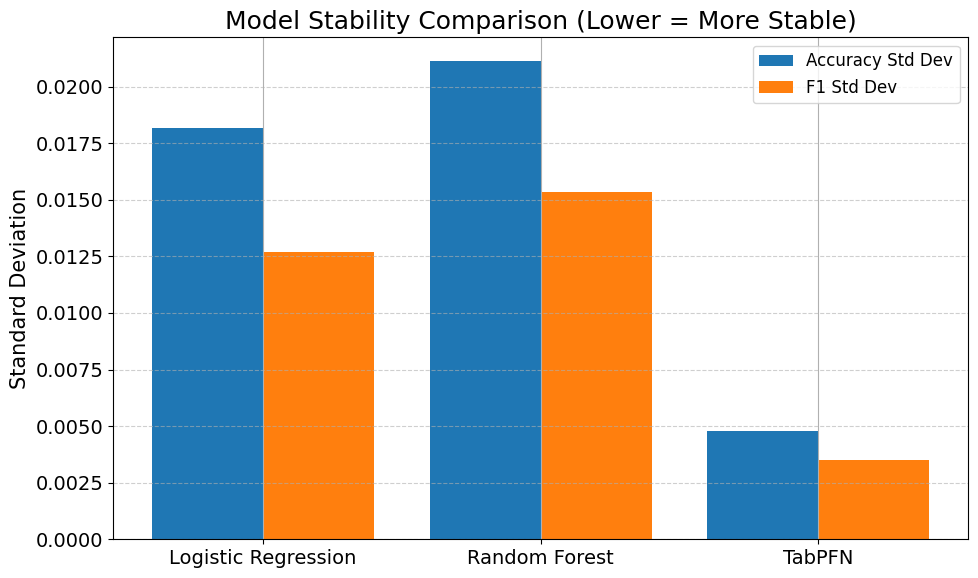

Generated:
stability_accuracy.png
stability_f1.png
stability_combined.png
stability_std_comparison.png


In [34]:
#Visualization 6 
#Stability eval : done on all 3 datasets with breast cancer
# ============================================================
# STEP 2: EXTRACT RUN NUMBER FROM CONDITION
# ============================================================

stability_df["run"] = (
    stability_df["condition"]
    .str.replace("run_", "", regex=False)
    .astype(int)
)


# ============================================================
# STEP 3: ACCURACY VS RUN
# ============================================================

accuracy_plot = stability_df.pivot(
    index="run",
    columns="model",
    values="accuracy"
)

plt.figure(figsize=(10,6))

accuracy_plot.plot(marker="o")

plt.title("Stability Analysis — Accuracy vs Run")
plt.ylabel("Accuracy")
plt.xlabel("Run")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/stability_accuracy.png", dpi=300)

plt.show()


# ============================================================
# STEP 4: F1 SCORE VS RUN
# ============================================================

f1_plot = stability_df.pivot(
    index="run",
    columns="model",
    values="f1_score"
)

plt.figure(figsize=(10,6))

f1_plot.plot(marker="o")

plt.title("Stability Analysis — F1 Score vs Run")
plt.ylabel("F1 Score")
plt.xlabel("Run")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/stability_f1.png", dpi=300)

plt.show()


# ============================================================
# STEP 5: COMBINED SUBPLOT (BEST FOR POSTER)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14,6))

accuracy_plot.plot(marker="o", ax=axes[0])
axes[0].set_title("Accuracy vs Run")
axes[0].set_xlabel("Run")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, linestyle="--", alpha=0.6)

f1_plot.plot(marker="o", ax=axes[1])
axes[1].set_title("F1 Score vs Run")
axes[1].set_xlabel("Run")
axes[1].set_ylabel("F1 Score")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/stability_combined.png", dpi=300)

plt.show()


# ============================================================
# STEP 6: STANDARD DEVIATION BAR PLOT (BEST SCIENTIFIC PROOF)
# ============================================================
# This directly shows stability — lower std = more stable

std_summary = stability_df.groupby("model").agg({
    "accuracy": "std",
    "f1_score": "std"
}).reset_index()

plt.figure(figsize=(10,6))

x = range(len(std_summary["model"]))

plt.bar(x, std_summary["accuracy"], width=0.4, label="Accuracy Std Dev")
plt.bar([i + 0.4 for i in x], std_summary["f1_score"], width=0.4, label="F1 Std Dev")

plt.xticks([i + 0.2 for i in x], std_summary["model"])

plt.title("Model Stability Comparison (Lower = More Stable)")
plt.ylabel("Standard Deviation")

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../results/stability_std_comparison.png", dpi=300)

plt.show()


# ============================================================
# DONE
# ============================================================

print("Generated:")
print("stability_accuracy.png")
print("stability_f1.png")
print("stability_combined.png")
print("stability_std_comparison.png")

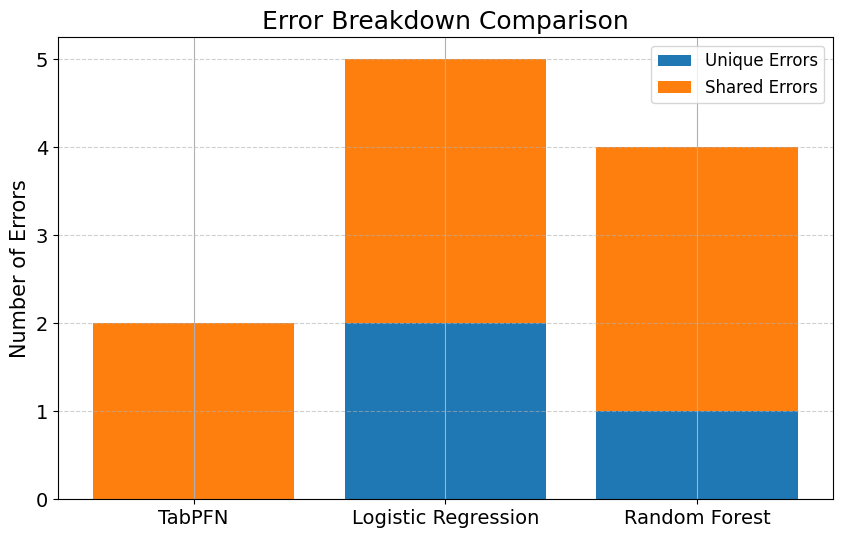

In [ ]:
#Visulization 7 - Breast cancer on the 3 datasets
# compute error rate
error_df["error_rate"] = error_df["total_errors"] / error_df["test_size"]

# Error breakdown plot
x = range(len(error_df))

plt.figure(figsize=(10,6))

plt.bar(x, error_df["unique_errors"], label="Unique Errors")

plt.bar(
    x,
    error_df["shared_errors"],
    bottom=error_df["unique_errors"],
    label="Shared Errors"
)

plt.xticks(x, error_df["model"])

plt.title("Error Breakdown Comparison")
plt.ylabel("Number of Errors")

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.savefig("../results/error_breakdown.png", dpi=300)

plt.show()